![DB Academy](./Includes/images/db-academy.png)

# Demo - Bakehouse Setup and Data Exploration

## Overview

Before creating a Genie Space, you need to understand the data it will use. 

In this short demo, you will quickly explore the **bakehouse** dataset, a fictional bakery franchise business.

During exploration you need to familiarize yourself with the tables, their relationships, and a key data quality issue. This context will help you make better decisions when configuring and curating Genie in the next demo.

## Learning Objectives

By the end of this demo, you will be able to:

1. **Identify the tables** in the bakehouse dataset and understand what each one contains.
2. **Understand the relationships** between tables using primary and foreign keys.
3. **Identify a data quality issue** - Specifically orphaned foreign keys between franchises and suppliers.

## REQUIRED - SELECT A COMPUTE ENVIRONMENT

<div style="
  border-left: 4px solid #f44336;
  background: #ffebee;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#c62828; margin-bottom:6px; font-size: 1.1em;">Select a Serverless SQL Warehouse</strong>
  <div style="color:#333;">

Before starting this notebook, select the required compute environment listed below.

- **Serverless SQL Warehouse (2X-Small is sufficient)**
  - Select **Compute** > **More** > **SQL Warehouse** > Select a SQL Warehouse you have access to.

**NOTE:** This notebook was **developed and tested using Serverless SQL Warehouse**. Other compute options may work but are not guaranteed to behave the same or support all features demonstrated.
  </div>
</div>

## A. Classroom Setup

1. Run the cell below to initialize your environment. This setup step will:
    - Assume that you have **permission to create a catalog**
    - Create a catalog named **labuser_YOUR_USER_NAME**
    - Create a schema named **genie_course_bakehouse**
    - Create the necessary tables (copies the **samples.bakehouse** data to your catalog with minor modifications)

In [0]:
%run ./Includes/Classroom-Setup-creating-genie-space

2. Run the cell below to view the tables in your **labuser_YOUR_USER_NAME.genie_course_bakehouse** schema.

    Confirm the following 5 tables exist:

    - **media_customer_reviews_gold**
    - **sales_customers_gold**
    - **sales_franchises_gold**
    - **sales_suppliers_gold**
    - **sales_transactions_gold**

In [0]:
SHOW TABLES IN genie_course_bakehouse;


<div style="
  border-left: 4px solid #1976d2;
  background: #e3f2fd;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#0d47a1; margin-bottom:6px; font-size: 1.1em;">
    Information
  </strong>
  <div style="color:#333;">

For this course, we assume a data pipeline is already running and producing the **gold tables** required for Genie.

These tables represent curated, analytics-ready data that Genie will use to answer questions.

  </div>
</div>

## B. Understanding the Bakehouse Dataset

Before creating a Genie space, it is important to understand the data that the space will use.

> The **bakehouse** dataset represents a fictional bakery franchise business with locations around the world. It includes data on customers, franchise locations, suppliers, sales transactions, and customer reviews.

| Table | Description | Rows |
|-------|-------------|------|
| **sales_customers_gold** | Customer profiles including name, email, location, and demographics | 300 |
| **sales_franchises_gold** | Bakery franchise locations with city, country, size, and geographic coordinates | 48 |
| **sales_suppliers_gold** | Ingredient suppliers with location and approval status | 27 |
| **sales_transactions_gold** | Sales transactions including product, quantity, price, and payment method | 3,333 |
| **media_customer_reviews_gold** | Customer reviews with free-text feedback and a sentiment label | 204 |

### B1. Preview the Tables
Run the queries below to quickly preview each table and understand the data you will be working with.

1. View the **sales_customers_gold** table.

    Notice it contains:
      - a **customerID** column
      - general customer information such as name, contact details, and location

In [0]:
-- Preview the sales_customers table
SELECT *
FROM sales_customers_gold;

2. View the **sales_franchises_gold** table.

    Notice it contains:
      - a **franchiseID** column
      - location details such as city, district, zip code, and country
      - franchise attributes such as size and supplier relationships (**supplierID** column)

In [0]:
-- Preview the sales_franchises table
SELECT *
FROM sales_franchises_gold;

3. View the **sales_suppliers_gold** table.

    Notice it contains:
      - a **supplierID** column
      - supplier details such as name, ingredient, and location
      - operational attributes such as size and approval status

In [0]:
-- Preview the sales_suppliers table
SELECT *
FROM sales_suppliers_gold;

4. View the **sales_transactions_gold** table.

    Notice it contains:
      - a **transactionID** column
      - relationships to customers and franchises through **customerID** and **franchiseID**
      - transactional details such as product, quantity, pricing, and total amount
      - payment information such as payment method and card number

In [0]:
-- Preview the sales_transactions table
SELECT *
FROM sales_transactions_gold;

5. View the **media_customer_reviews_gold** table.

    Notice it contains:
      - a **review** column with unstructured text data
      - a **ref** column linking reviews to specific locations (**sales_franchises_gold.franchiseID**)
      - a **review_date** for when the review was created
      - a **flag** classification indicating positive, negative, or mixed feedback
        - Created for you using the `ai_analyze_sentiment` function:
        [AWS](https://docs.databricks.com/aws/en/sql/language-manual/functions/ai_analyze_sentiment) |
        [Azure](https://learn.microsoft.com/en-us/azure/databricks/sql/language-manual/functions/ai_analyze_sentiment) |
        [GCP](https://docs.databricks.com/gcp/en/sql/language-manual/functions/ai_analyze_sentiment)


In [0]:
SELECT *
FROM media_customer_reviews_gold;

6. Join the **sales_franchises_gold** and **sales_suppliers_gold** tables to find if all franchises have a supplier documented.

In [0]:
SELECT
  f.franchiseID,
  COUNT(s.supplierID) AS supplier_count
FROM sales_franchises_gold f
LEFT JOIN sales_suppliers_gold s 
  ON f.supplierID = s.supplierID
GROUP BY f.franchiseID

<div style="
  border-left: 4px solid #ff9800;
  background: #fff3e0;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#e65100; margin-bottom:6px; font-size: 1.1em;">
    Warning
  </strong>
  <div style="color:#333;">

Notice that not all **franchises** have an associated **supplier** in this synthetic data.

**Summary Counts**

| has_valid_supplier | count |
|-------------------|-------|
| No                | 21    |
| Yes               | 27    |

  </div>
</div>

<div style="
  border-left: 4px solid #1976d2;
  background: #e3f2fd;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#0d47a1; margin-bottom:6px; font-size: 1.1em;">
    A Note on Data Exploration
  </strong>
  <div style="color:#333;">

In production scenarios, it is important to **thoroughly explore and profile your data** before building a Genie Space. 

Understanding distributions, nulls, edge cases, and business logic embedded in the data.

For this training, we have done a **brief, focused exploration**. Just enough to understand the tables and one key data quality issue before moving on to Genie.

  </div>
</div>


## C. Genie Project Architecture Overview
<br></br>
<div style="max-width: 1280px; margin: 0 auto; font-family: sans-serif; color: #0b2026;">

<!-- TITLE BAR -->
<div style="background: #1B5162; color: white; border-radius: 8px; padding: 20px 28px; margin-bottom: 18px;">
  <div style="font-size: 22pt; font-weight: 700; margin-bottom: 6px;">Genie Project Architecture</div>
  <div style="font-size: 15pt; font-weight: 400; line-height: 1.45; opacity: 0.95;">Let&rsquo;s view the project architecture for Genie. The goal is to link all of our Unity Catalog tables to a Genie Space where consumers can <b>ask questions in natural language to obtain results.</b></div>
</div>

<!-- BEST PRACTICE CALLOUT -->
<div style="background: #FFF6F4; border-left: 4px solid #FF5F46; border-radius: 6px; padding: 12px 18px; margin-bottom: 22px; font-size: 14pt; line-height: 1.5;">
  <span style="font-size: 12pt; font-weight: 700; letter-spacing: 1.5px; color: #B83A24; text-transform: uppercase; display: block; margin-bottom: 4px;">Best Practice</span>
  It&rsquo;s best for a <b>data domain expert</b> to set up a Genie Space with <b>stakeholder involvement</b>.
</div>

<!-- FAN-IN/FAN-OUT ARCHITECTURE -->
<div style="display: grid; grid-template-columns: 1.35fr auto 1fr auto 0.85fr; gap: 0; align-items: center;">

  <!-- LEFT COLUMN: SOURCE TABLES -->
  <div>
    <div style="font-size: 12pt; font-weight: 700; letter-spacing: 2px; color: #1B5162; text-transform: uppercase; text-align: center; margin-bottom: 12px;">Unity Catalog Tables</div>
    <div style="display: flex; flex-direction: column; gap: 10px;">
    <div style="background: #FFFFFF; border: 2px solid #1B5162; border-left: 6px solid #1B5162; border-radius: 8px; padding: 10px 14px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 4px;">
        <svg width="22" height="22" viewBox="0 0 24 24" fill="none" stroke="#1B5162" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><ellipse cx="12" cy="5" rx="9" ry="3"></ellipse><path d="M3 5v6c0 1.66 4.03 3 9 3s9-1.34 9-3V5"></path><path d="M3 11v6c0 1.66 4.03 3 9 3s9-1.34 9-3v-6"></path></svg>
        <div style="font-family: monospace; font-size: 14pt; font-weight: 700; color: #0b2026;">sales_customers_gold</div>
      </div>
      <div style="font-size: 14pt; color: #5A6F77; font-style: italic; line-height: 1.35; padding-left: 30px;">Customer profiles and locations</div>
    </div>
    <div style="background: #FFFFFF; border: 2px solid #1B5162; border-left: 6px solid #1B5162; border-radius: 8px; padding: 10px 14px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 4px;">
        <svg width="22" height="22" viewBox="0 0 24 24" fill="none" stroke="#1B5162" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><ellipse cx="12" cy="5" rx="9" ry="3"></ellipse><path d="M3 5v6c0 1.66 4.03 3 9 3s9-1.34 9-3V5"></path><path d="M3 11v6c0 1.66 4.03 3 9 3s9-1.34 9-3v-6"></path></svg>
        <div style="font-family: monospace; font-size: 14pt; font-weight: 700; color: #0b2026;">sales_franchises_gold</div>
      </div>
      <div style="font-size: 14pt; color: #5A6F77; font-style: italic; line-height: 1.35; padding-left: 30px;">Franchise locations and size</div>
    </div>
    <div style="background: #FFFFFF; border: 2px solid #1B5162; border-left: 6px solid #1B5162; border-radius: 8px; padding: 10px 14px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 4px;">
        <svg width="22" height="22" viewBox="0 0 24 24" fill="none" stroke="#1B5162" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><ellipse cx="12" cy="5" rx="9" ry="3"></ellipse><path d="M3 5v6c0 1.66 4.03 3 9 3s9-1.34 9-3V5"></path><path d="M3 11v6c0 1.66 4.03 3 9 3s9-1.34 9-3v-6"></path></svg>
        <div style="font-family: monospace; font-size: 14pt; font-weight: 700; color: #0b2026;">sales_suppliers_gold</div>
      </div>
      <div style="font-size: 14pt; color: #5A6F77; font-style: italic; line-height: 1.35; padding-left: 30px;">Ingredient suppliers</div>
    </div>
    <div style="background: #FFFFFF; border: 2px solid #1B5162; border-left: 6px solid #1B5162; border-radius: 8px; padding: 10px 14px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 4px;">
        <svg width="22" height="22" viewBox="0 0 24 24" fill="none" stroke="#1B5162" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><ellipse cx="12" cy="5" rx="9" ry="3"></ellipse><path d="M3 5v6c0 1.66 4.03 3 9 3s9-1.34 9-3V5"></path><path d="M3 11v6c0 1.66 4.03 3 9 3s9-1.34 9-3v-6"></path></svg>
        <div style="font-family: monospace; font-size: 14pt; font-weight: 700; color: #0b2026;">sales_transactions_gold</div>
      </div>
      <div style="font-size: 14pt; color: #5A6F77; font-style: italic; line-height: 1.35; padding-left: 30px;">Sales transactions and revenue</div>
    </div>
    <div style="background: #FFFFFF; border: 2px solid #1B5162; border-left: 6px solid #1B5162; border-radius: 8px; padding: 10px 14px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 4px;">
        <svg width="22" height="22" viewBox="0 0 24 24" fill="none" stroke="#1B5162" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><ellipse cx="12" cy="5" rx="9" ry="3"></ellipse><path d="M3 5v6c0 1.66 4.03 3 9 3s9-1.34 9-3V5"></path><path d="M3 11v6c0 1.66 4.03 3 9 3s9-1.34 9-3v-6"></path></svg>
        <div style="font-family: monospace; font-size: 14pt; font-weight: 700; color: #0b2026;">media_customer_reviews_gold</div>
      </div>
      <div style="font-size: 14pt; color: #5A6F77; font-style: italic; line-height: 1.35; padding-left: 30px;">Reviews and sentiment</div>
    </div>
    </div>
  </div>

  <!-- LEFT ARROW BUNDLE -->
  <div style="display: flex; flex-direction: column; align-items: center; padding: 0 14px;">
    <div style="font-size: 32pt; color: #618794; line-height: 1;">&rarr;</div>
    <div style="font-size: 12pt; color: #618794; font-style: italic; margin-top: 4px; text-align: center; max-width: 90px;">governed data</div>
  </div>

  <!-- CENTER: GENIE HUB -->
  <div style="background: #F9F7F4; border: 3px solid #FF5F46; border-radius: 14px; padding: 22px 18px; box-shadow: 0 6px 20px rgba(255,95,70,0.18); text-align: center; position: relative;">
    <div style="position: absolute; top: -12px; left: 50%; transform: translateX(-50%); background: #FF5F46; color: white; font-size: 11pt; font-weight: 700; letter-spacing: 1.5px; padding: 3px 14px; border-radius: 12px;">GENIE SPACE</div>
    <div style="margin: 10px 0 14px 0;">
      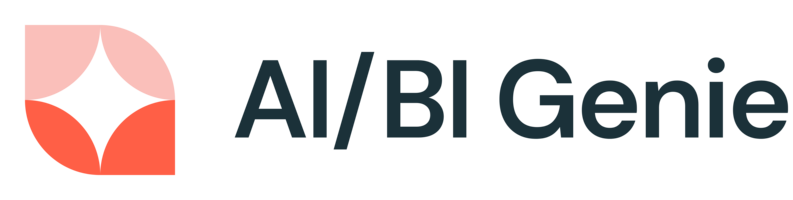
    </div>
    <div style="font-size: 16pt; font-weight: 700; color: #0b2026; line-height: 1.3; margin-bottom: 10px;">Ask questions in<br>natural language</div>
    <div style="background: #FFFFFF; border: 1.5px dashed #FF5F46; border-radius: 18px 18px 18px 4px; padding: 8px 14px; font-size: 13pt; font-style: italic; color: #5A6F77; text-align: left; margin-top: 12px;">
      &ldquo;What were our top 5 selling products last quarter?&rdquo;
    </div>
  </div>

  <!-- RIGHT ARROW BUNDLE -->
  <div style="display: flex; flex-direction: column; align-items: center; padding: 0 14px;">
    <div style="font-size: 32pt; color: #618794; line-height: 1;">&rarr;</div>
    <div style="font-size: 12pt; color: #618794; font-style: italic; margin-top: 4px; text-align: center; max-width: 90px;">answers &amp; charts</div>
  </div>

  <!-- RIGHT COLUMN: CONSUMERS -->
  <div>
    <div style="font-size: 12pt; font-weight: 700; letter-spacing: 2px; color: #00A972; text-transform: uppercase; text-align: center; margin-bottom: 12px;">Consumers</div>
    <div style="display: flex; flex-direction: column; gap: 12px;">
    <div style="background: #FFFFFF; border: 2px solid #00A972; border-left: 6px solid #00A972; border-radius: 8px; padding: 14px 16px; display: flex; align-items: center; gap: 12px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <svg width="26" height="26" viewBox="0 0 24 24" fill="none" stroke="#00A972" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M20 21v-2a4 4 0 0 0-4-4H8a4 4 0 0 0-4 4v2"></path><circle cx="12" cy="7" r="4"></circle></svg>
      <div style="font-size: 15pt; font-weight: 700; color: #0b2026;">Analysts</div>
    </div>
    <div style="background: #FFFFFF; border: 2px solid #00A972; border-left: 6px solid #00A972; border-radius: 8px; padding: 14px 16px; display: flex; align-items: center; gap: 12px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <svg width="26" height="26" viewBox="0 0 24 24" fill="none" stroke="#00A972" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M20 21v-2a4 4 0 0 0-4-4H8a4 4 0 0 0-4 4v2"></path><circle cx="12" cy="7" r="4"></circle></svg>
      <div style="font-size: 15pt; font-weight: 700; color: #0b2026;">Business Users</div>
    </div>
    <div style="background: #FFFFFF; border: 2px solid #00A972; border-left: 6px solid #00A972; border-radius: 8px; padding: 14px 16px; display: flex; align-items: center; gap: 12px; box-shadow: 0 1px 4px rgba(27,49,57,0.06);">
      <svg width="26" height="26" viewBox="0 0 24 24" fill="none" stroke="#00A972" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M20 21v-2a4 4 0 0 0-4-4H8a4 4 0 0 0-4 4v2"></path><circle cx="12" cy="7" r="4"></circle></svg>
      <div style="font-size: 15pt; font-weight: 700; color: #0b2026;">Franchise Managers</div>
    </div>
    </div>
  </div>

</div>

<!-- BOTTOM BAND: foundation note -->
<div style="margin-top: 24px; background: linear-gradient(135deg, #1B5162 0%, #0b2026 100%); color: #ffffff; border-radius: 8px; padding: 14px 22px; text-align: center;">
  <div style="font-size: 11pt; letter-spacing: 2.5px; text-transform: uppercase; color: #B7CDD5; font-weight: 700; margin-bottom: 4px;">Foundation</div>
  <div style="font-size: 14pt; color: #ffffff;">Unity Catalog &middot; one governed copy of your data &middot; permissions enforced end to end</div>
</div>

</div>

<div style="
  border-left: 4px solid #1976d2;
  background: #e3f2fd;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#0d47a1; margin-bottom:6px; font-size: 1.1em;">
    Metric Views as a source for Genie are recommended
  </strong>
  <div style="color:#333;">

Instead of referencing tables directly in Genie, **it's recommended that you use Metric Views**. However, to keep this course focused on **Genie**, we will reference tables directly.

**Learning metric views in depth is outside the scope of this course.**

#### Metric views provide a **central semantic layer** that standardizes how business metrics and dimensions are defined across your organization.

<img src="./Includes/images/intro-to-genie-space-lecture/metric-view-overview.png"
     alt="OLAP Overview"
     width="850">

- They allow you to define business logic once and reuse it consistently across **Genie spaces, AI/BI dashboards, and other analytics experiences**.

- This ensures that metrics like revenue, customers, or orders are calculated and interpreted the **same way everywhere**, reducing inconsistency across teams.

- Metric views are **code-managed in Unity Catalog**, making them reusable, versionable, and easier to govern at scale.

- Many of the concepts you configure in Genie (descriptions, synonyms, logic) can also be defined in metric views, but at a **shared, organization-wide level** instead of per space.

**NOTE:** In this course, we focus on building and curating a Genie Space directly. In production, many teams layer Genie on top of metric views to ensure consistent business semantics.

View the documentation below or check out the [Building Semantic Models in Databricks with UC Metric Views](https://www.databricks.com/training/catalog/building-semantic-models-in-databricks-with-uc-metric-views-4962) Databricks training.

- Unity Catalog Metric Views:
[AWS](https://docs.databricks.com/aws/en/metric-views/) |
[Azure](https://learn.microsoft.com/en-us/azure/databricks/metric-views/) |
[GCP](https://docs.databricks.com/gcp/en/metric-views/)


  </div>
</div>


## D. Conclusion

In this demo, you:

1. Previewed all five bakehouse gold tables and identified their key columns.
2. Reviewed the relationships between tables using primary and foreign keys.
3. Discovered that **21 out of 48 franchises** have a `supplierID` that does not match any record in the suppliers table. This is a data quality issue that can affect how Genie generates joins.


&copy; <span id="dbx-year"></span> Databricks, Inc. All rights reserved.
Apache, Apache Spark, Spark, the Spark Logo, Apache Iceberg, Iceberg, and the Apache Iceberg logo are trademarks of the <a href="https://www.apache.org/" target="_blank">Apache Software Foundation</a>.<br/><br/><a href="https://databricks.com/privacy-policy" target="_blank">Privacy Policy</a> | <a href="https://databricks.com/terms-of-use" target="_blank">Terms of Use</a> | <a href="https://help.databricks.com/" target="_blank">Support</a>
<script>
  document.getElementById("dbx-year").textContent = new Date().getFullYear();
</script>